Importação de libs

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

Camadas de neuronios e compilação do código. Simples e sequencial para sabermos a quanto será no array y.

In [ ]:
model = keras.Sequential([keras.layers.Dense(units = 1, input_shape=[1])])
model.compile(optimizer='sgd', loss='mean_squared_error')

xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

model.fit(xs, ys, epochs=500)
print(model.predict(np.array([10.0])))


Sequencial de pares e impar, meu código e o "normal"

In [ ]:
X = array([1, 2, 3, 4, 5, 9, 4, 2, 6, 7]).reshape(-1, 1)  # Shape (10, 1)
Y = array([1, 0, 1, 0, 1, 1, 0, 0, 0, 1])

mod = Sequential()
mod.add(Dense(8, activation='relu', input_dim=1))  # Camada oculta com ReLU
mod.add(Dense(1, activation='sigmoid'))            # Saída binária

#compile
mod.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

infer_model = mod.fit(X, Y, epochs=100, verbose=1)  # Treina o modelo

In [ ]:
# Números para teste
test_numbers = array([11, 12, 13, 14, 15]).reshape(-1, 1)

# Previsões (probabilidades entre 0 e 1)
predictions = model.predict(test_numbers)

# Convertendo para classes (0 ou 1)
predicted_classes = (predictions > 0.5).astype(int)

# Exibindo resultados
for num, pred in zip(test_numbers.flatten(), predicted_classes.flatten()):
    print(f"Número: {num} → Predição: {'Ímpar (1)' if pred == 1 else 'Par (0)'}")

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --- 1. Gerar Dados de Treinamento (Array Grande) ---
np.random.seed(42)  # Para reprodutibilidade
X_train = np.random.randint(1, 1000, size=(10000, 1))  # 10.000 números entre 1 e 1000
Y_train = (X_train % 2).astype(int).flatten()  # 0 para par, 1 para ímpar

# --- 2. Criar Conjunto de Teste (Dados Não Vistos) ---
X_test = np.random.randint(1001, 2000, size=(500, 1))  # 500 números entre 1001 e 2000
Y_test = (X_test % 2).astype(int).flatten()

# --- 3. Modelo ---
model = Sequential()
model.add(Dense(16, activation='relu', input_dim=1))  # Camada oculta com 16 neurônios
model.add(Dense(1, activation='sigmoid'))             # Saída binária
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- 4. Treinamento ---
history = model.fit(X_train, Y_train, epochs=20, batch_size=32,
                    validation_split=0.2, verbose=1)  # 20% para validação

# --- 5. Avaliação no Conjunto de Teste ---
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"\nAcurácia nos dados de teste (não vistos): {accuracy*100:.2f}%")

# --- 6. Testar com Números Específicos ---
test_numbers = np.array([123, 456, 789, 1000, 2001]).reshape(-1, 1)
predictions = model.predict(test_numbers)
predicted_classes = (predictions > 0.5).astype(int)

print("\nClassificação de Números de Teste:")
for num, pred in zip(test_numbers.flatten(), predicted_classes.flatten()):
    print(f"Número: {num} → {'Ímpar (1)' if pred == 1 else 'Par (0)'}")

Meu código para identificar peças de roupas.


In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data() #(train_images, train_labels) respectivamente a minha bota ou outra peça de roupa e minha label (quero classificar de 0 a 9)

training_images = train_images / 255.0
test_images = test_images / 255.0

model = keras.Sequential({
    keras.layers.Flatten(input_shape = (28, 28)), #normalização da imagem em 28x28 pixels
    keras.layers.Dense(128, activation = tf.nn.relu), #Entradas, no caso são 128 camadas com ativação em relu
    keras.layers.Dense(10, activation = tf.nn.softmax) #saida, como dito antes, tenho que classificar de 0 até 9 então eu posso ter 10 saídas
    })

model.compile(optimizer = 'adam', loss = 'spare_categorical_crossentropy')
model.fit(train_images, train_labels, epochs = 5)


NameError: name 'keras' is not defined

Para modelos que leem imagens...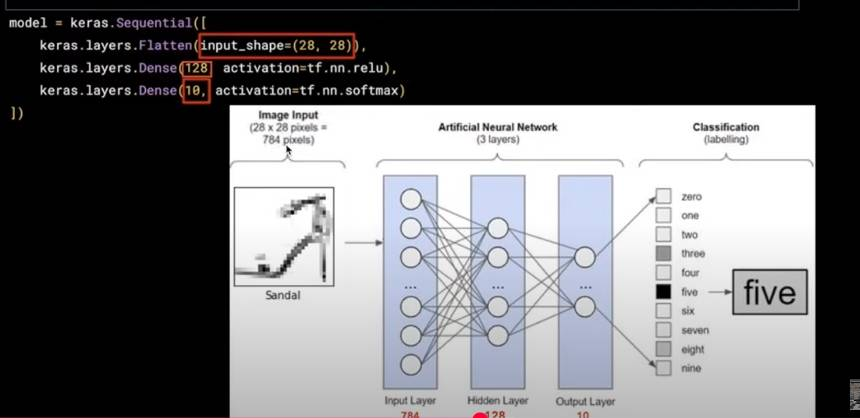

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Carregar dados
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalização (já correta no seu código)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Definir modelo
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Achata a imagem 28x28 para um vetor de 784 pixels
    keras.layers.Dense(128, activation='relu'),  # Camada oculta com 128 neurônios e ReLU
    keras.layers.Dense(10, activation='softmax')  # Camada de saída com 10 classes (0 a 9)
])

# Compilar o modelo (corrigindo o nome da loss e adicionando accuracy)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Nome correto!
    metrics=['accuracy']  # Adicionado para monitorar a acurácia
)

# Treinar o modelo
model.fit(train_images, train_labels, epochs=5)

# Avaliar no conjunto de teste (opcional)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Acurácia no teste: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7773 - loss: 0.6414
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8604 - loss: 0.3925
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8745 - loss: 0.3455
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8846 - loss: 0.3158
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8903 - loss: 0.2969
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8680 - loss: 0.3621
Acurácia no teste: 0.8674
